In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd


dpi = 150
mpl.rcParams['figure.dpi'] = dpi
sns.set_theme(context='notebook', style='ticks')

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from spatial_decompostion import *

In [2]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/" + x

In [3]:
ds = xr.open_mfdataset(datadir("native_resolution/CM4Xp125_native_resolution_example_2010.zarr"))

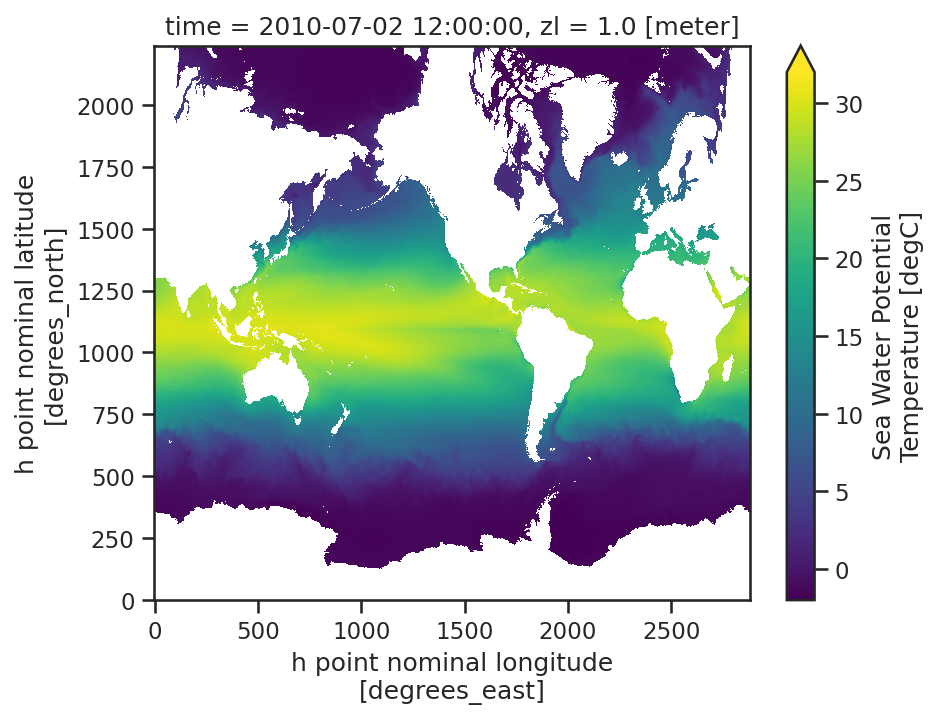

In [16]:
ds.thetao.isel(zl = 0).plot(vmin = -2, vmax = 32)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath

def longest_isobath_mask(depth, lon, lat, level=1000.0):
    d = np.asarray(depth)
    x = np.asarray(lon)
    y = np.asarray(lat)

    fig, ax = plt.subplots()
    cs = ax.contour(x, y, d, levels=[level])  # lon/lat space, no cartopy
    plt.close(fig)

    segs = cs.allsegs[0]
    segs = [s for s in segs if s.size]
    if not segs:
        raise ValueError("No contour segments found at requested level.")

    iso = max(segs, key=lambda s: s.shape[0])  # (N,2) with columns [lon, lat]

    path = mpath.Path(iso)
    pts = np.column_stack([x.ravel(), y.ravel()])
    inside = path.contains_points(pts).reshape(d.shape)

    # determine which side is the "deeper than level" side and return that as the mask
    deeper = d > level
    if np.nanmean(deeper[inside]) >= 0.5:
        return inside, iso
    else:
        return ~inside, iso

# usage:
# depth = da.deptho.values
# lon   = da.geolon.values
# lat   = da.geolat.values
# mask1000_deeper, iso1000 = longest_isobath_mask(depth, lon, lat, level=1000.0)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath

def longest_isobath_vertices(depth, lon, lat, level=1000.0):
    d = np.asarray(depth)
    x = np.asarray(lon)
    y = np.asarray(lat)

    fig, ax = plt.subplots()
    cs = ax.contour(x, y, d, levels=[level])
    plt.close(fig)

    segs = cs.allsegs[0]
    segs = [s for s in segs if s.size]
    if not segs:
        raise ValueError(f"No contour segments found at level={level}.")

    iso = max(segs, key=lambda s: s.shape[0])  # (N,2): [lon, lat]
    return iso[:, 0], iso[:, 1]


Text(-50, -58, '1000 m isobath')

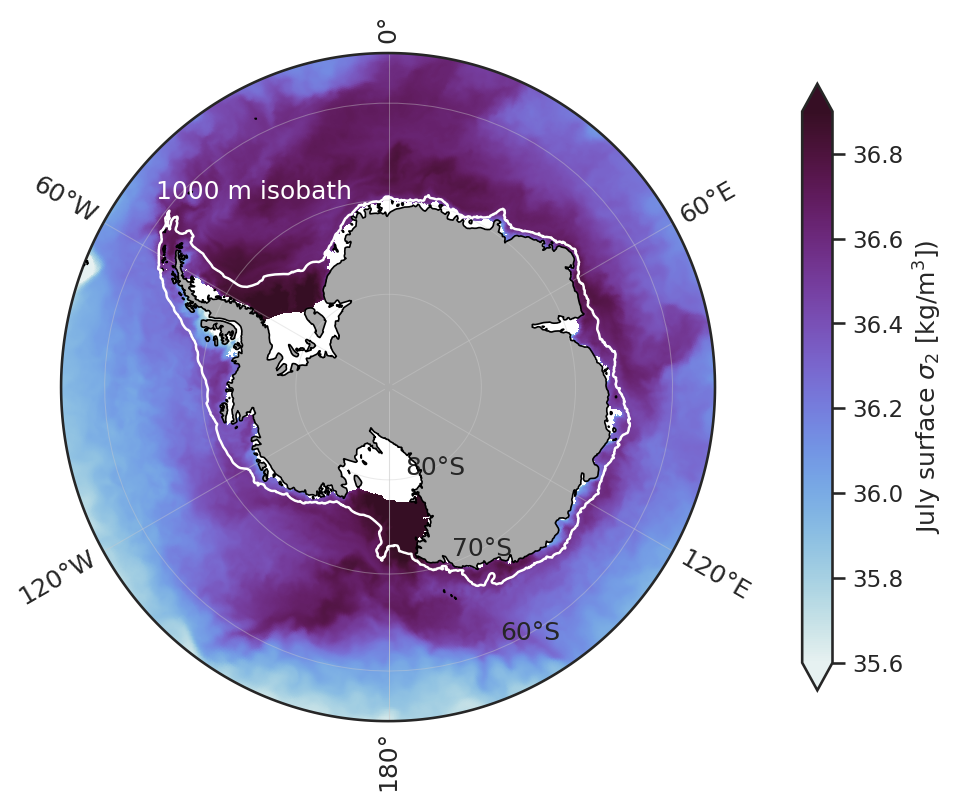

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

da = ds.sigma2.isel(zl=0)

fig = plt.figure(figsize=(7.5, 7.5))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

levels = np.arange(35.6, 37.0, 0.1)

pc = da.plot(
    ax=ax,
    x="geolon",
    y="geolat",
    cmap=cmo.dense,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
    vmin=float(levels.min()),
    vmax=float(levels.max()),
    extend="both",
)

ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="darkgrey", zorder=2)
ax.coastlines(linewidth=0.8, zorder=3)

theta = np.linspace(0, 2*np.pi, 361)
center = np.array([0.5, 0.5])
radius = 0.5
verts = np.column_stack([np.sin(theta), np.cos(theta)])
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    alpha=0.4,
    x_inline=False,   # longitude labels outside
    y_inline=True,    # latitude labels inline
    zorder=4,
)
gl.xlocator = FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = FixedLocator(np.arange(-90, -49, 10))
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

# gl.xlabel_style = {"size": 10}
# gl.ylabel_style = {"size": 10}
def _set_lat_label_rotation(event=None):
    arts = []
    for name in ("ylabel_artists", "_ylabel_artists", "label_artists"):
        v = getattr(gl, name, None)
        if v is None:
            continue
        if isinstance(v, dict):
            arts.extend([t for t in v.values() if t is not None])
        else:
            arts.extend([t for t in v if t is not None])

    for t in arts:
        t.set_rotation(45)
        t.set_rotation_mode("anchor")

fig.canvas.mpl_connect("draw_event", _set_lat_label_rotation)
fig.canvas.draw()

fig.colorbar(
    pc, ax=ax, shrink=0.7, pad=0.1, extend="both",
    label=r"July surface $\sigma_2$ [kg/m$^3$])", orientation="vertical"
)

ax.set_title("")

depth = ds.sel(yh=slice(0, 600)).deptho
lon = depth["geolon"] if "geolon" in depth.coords else ds["geolon"]
lat = depth["geolat"] if "geolat" in depth.coords else ds["geolat"]

lon1000, lat1000 = longest_isobath_vertices(depth.values, lon.values, lat.values, level=1000.0)

ax.plot(
    lon1000, lat1000,
    color="w", linewidth=1.2,
    transform=ccrs.PlateCarree(),
    zorder=6,
)

iso_handle = Line2D([0], [0], color="w", lw=1.2, label="1000 m isobath")
ax.text(
    -50, -58, "1000 m isobath",
    transform=ccrs.PlateCarree(),
    color="w", fontsize=12,
    ha="left", va="center",
    zorder=7,
)